In [ ]:
!pip install -q --upgrade transformers datasets peft evaluate scikit-learn pandas pyarrow wandb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model


In [ ]:
# Global parameters
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

device = "cuda" if torch.cuda.is_available() else "cpu"
MAX_LEN = 128
NUM_EPOCHS = 10


In [ ]:
# ---------------------
# Data loading functions
# ---------------------
def load_and_preprocess_data(filename):
    """Load a parquet file and preprocess the dataset for emotion labels."""
    df = pd.read_parquet(filename)
    df = df.dropna(subset=['text'])
    df = df[df['text'].str.strip() != '']
    df = df[df[emotion_labels].sum(axis=1) > 0]
    df[emotion_labels] = df[emotion_labels].fillna(0).astype(int)

    return Dataset.from_pandas(df)

def preprocess_function(examples, tokenizer):
    """Tokenize text and binarize emotion labels for a batch of examples."""
    tokenized = tokenizer(examples["text"], padding="max_length", truncation=True, max_length=MAX_LEN)
    batch_labels = []
    for i in range(len(examples["text"])):
        sample_labels = [label for label in emotion_labels if examples[label][i] == 1]
        batch_labels.append(sample_labels)

    mlb = MultiLabelBinarizer(classes=emotion_labels)
    tokenized["labels"] = mlb.fit_transform(batch_labels).astype(np.float32)
    return tokenized

In [ ]:
# ---------------------
# Metrics Computation Functions
# ---------------------
def get_all_metrics(trainer, dataset, threshold=0.3):
    """
    Compute overall (micro-averaged) metrics as well as per-emotion precision, recall, and F1 scores.

    Returns:
        overall_metrics: dict with keys "accuracy", "f1", "precision", "recall"
        per_emotion: dict where each key is an emotion and the value is {precision, recall, f1}
    """
    eval_output = trainer.predict(test_dataset=dataset)
    logits = eval_output.predictions
    labels = eval_output.label_ids
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs > threshold).astype("int32")
    labels = labels.astype("int32")

    overall_metrics = {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="micro"),
        "precision": precision_score(labels, preds, average="micro", zero_division=0),
        "recall": recall_score(labels, preds, average="micro")
    }

    per_emotion = {}
    for idx, emotion in enumerate(emotion_labels):
        prec = precision_score(labels[:, idx], preds[:, idx], zero_division=0)
        rec = recall_score(labels[:, idx], preds[:, idx], zero_division=0)
        f1_sc = f1_score(labels[:, idx], preds[:, idx], zero_division=0)
        per_emotion[emotion] = {"precision": prec, "recall": rec, "f1": f1_sc}

    return overall_metrics, per_emotion

In [ ]:
# ---------------------
# Experiment Runner Function
# ---------------------
def run_experiment(model_checkpoint, train_file, test_file):
    """
    Run training and evaluation experiment for a given model checkpoint.

    Returns:
        results: dictionary with keys "overall_train", "per_emotion_train", "overall_test", "per_emotion_test"
    """
    print(f"\n=== Running experiment with checkpoint: {model_checkpoint} ===")
    raw_train = load_and_preprocess_data(train_file)
    raw_test = load_and_preprocess_data(test_file)

    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    tokenized_train = raw_train.map(lambda x: preprocess_function(x, tokenizer),
                                    remove_columns=raw_train.column_names, batched=True)
    tokenized_test = raw_test.map(lambda x: preprocess_function(x, tokenizer),
                                  remove_columns=raw_test.column_names, batched=True)

    lora_config = LoraConfig(
        r=32,
        lora_alpha=32,
        lora_dropout=0.1,
        bias="none",
        task_type="SEQ_CLS",
        target_modules=["query", "value"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(emotion_labels),
        problem_type="multi_label_classification"
    ).to(device)
    peft_model = get_peft_model(model, lora_config)
    peft_model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=f"lora-{model_checkpoint}-emotion",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=NUM_EPOCHS,
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=peft_model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_train,
        compute_metrics=lambda eval_pred: {}
    )

    trainer.train()

    overall_train, per_emotion_train = get_all_metrics(trainer, tokenized_train)
    overall_test, per_emotion_test = get_all_metrics(trainer, tokenized_test)

    print("Train Overall Metrics:", overall_train)
    print("Test Overall Metrics:", overall_test)

    print("\nTrain Per-Emotion Metrics:")
    for emotion, metrics in per_emotion_train.items():
        print(f"  {emotion}: {metrics}")
    print("\nTest Per-Emotion Metrics:")
    for emotion, metrics in per_emotion_test.items():
        print(f"  {emotion}: {metrics}")

    return {
        "overall_train": overall_train,
        "per_emotion_train": per_emotion_train,
        "overall_test": overall_test,
        "per_emotion_test": per_emotion_test
    }


In [ ]:
# ---------------------
# Plotting Functions
# ---------------------
def plot_per_emotion_metrics(per_emotion_dict, model_name, dataset_type="Test"):
    """
    Plot a grouped bar chart for per-emotion metrics (precision, recall, f1) for one model.

    per_emotion_dict: dict with keys as emotions and values as sub-dicts containing "precision", "recall", "f1"
    """
    emotions = list(per_emotion_dict.keys())
    metrics_names = ["precision", "recall", "f1"]
    data = {m: [per_emotion_dict[e][m] for e in emotions] for m in metrics_names}
    df = pd.DataFrame(data, index=emotions)
    ax = df.plot(kind="bar", figsize=(10, 6))
    ax.set_title(f"{dataset_type} Per-Emotion Metrics for {model_name}")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_overall_metrics(overall_dict, model_names, dataset_type="Test"):
    """
    Plot overall (aggregated) metrics for all models side by side.

    overall_dict: dict where keys are model names and values are dicts with overall metrics.
    """
    metrics_names = ["accuracy", "precision", "recall", "f1"]
    data = {m: [overall_dict[model][m] for model in model_names] for m in metrics_names}
    df = pd.DataFrame(data, index=model_names)
    ax = df.plot(kind="bar", figsize=(8, 6))
    ax.set_title(f"{dataset_type} Overall Metrics Comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()




=== Running experiment with checkpoint: xlm-roberta-base ===


Map:   0%|          | 0/1869 [00:00<?, ? examples/s]

Map:   0%|          | 0/1882 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 1,774,854 || all params: 279,823,116 || trainable%: 0.6343


...

Map:   0%|          | 0/1882 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at castorini/afriberta_large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 1,578,246 || all params: 127,213,836 || trainable%: 1.2406


Step,Training Loss
500,0.397100
1000,0.319600
1500,0.295500
2000,0.286000


Train Overall Metrics: {'accuracy': 0.49491706795077584, 'f1': 0.7331177477648849, 'precision': 0.6697949252693778, 'recall': 0.8096638655462185}
Test Overall Metrics: {'accuracy': 0.43889479277364507, 'f1': 0.6800454373343431, 'precision': 0.6288515406162465, 'recall': 0.7403132728771641}

Train Per-Emotion Metrics:
  anger: {'precision': 0.6046511627906976, 'recall': 0.7647058823529411, 'f1': 0.6753246753246753}
  disgust: {'precision': 0.75, 'recall': 0.7659574468085106, 'f1': 0.7578947368421053}
  fear: {'precision': 0.7107843137254902, 'recall': 0.8868501529051988, 'f1': 0.7891156462585034}
  joy: {'precision': 0.7546583850931677, 'recall': 0.759375, 'f1': 0.7570093457943925}
  sadness: {'precision': 0.6485260770975056, 'recall': 0.884080370942813, 'f1': 0.7482014388489209}
  surprise: {'precision': 0.6246973365617433, 'recall': 0.7392550143266475, 'f1': 0.6771653543307087}

Test Per-Emotion Metrics:
  anger: {'precision': 0.56, 'recall': 0.6698564593301436, 'f1': 0.61002178649237

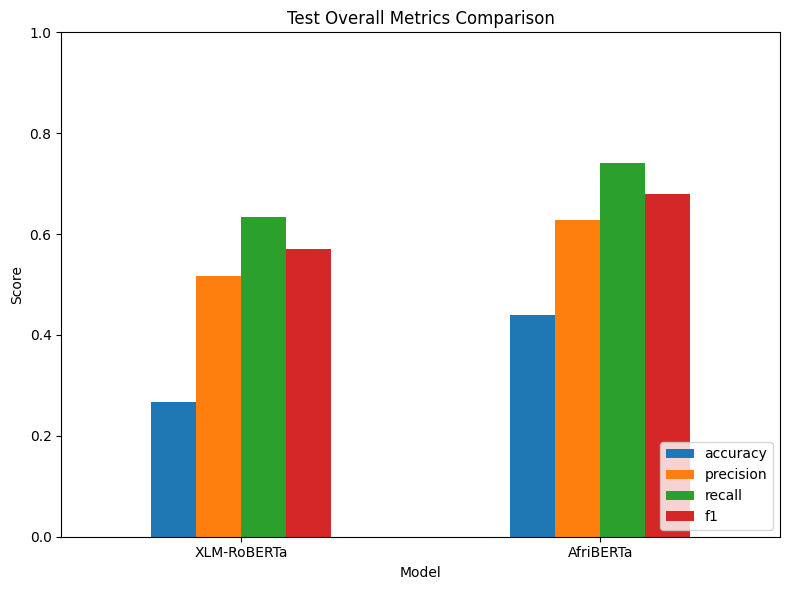

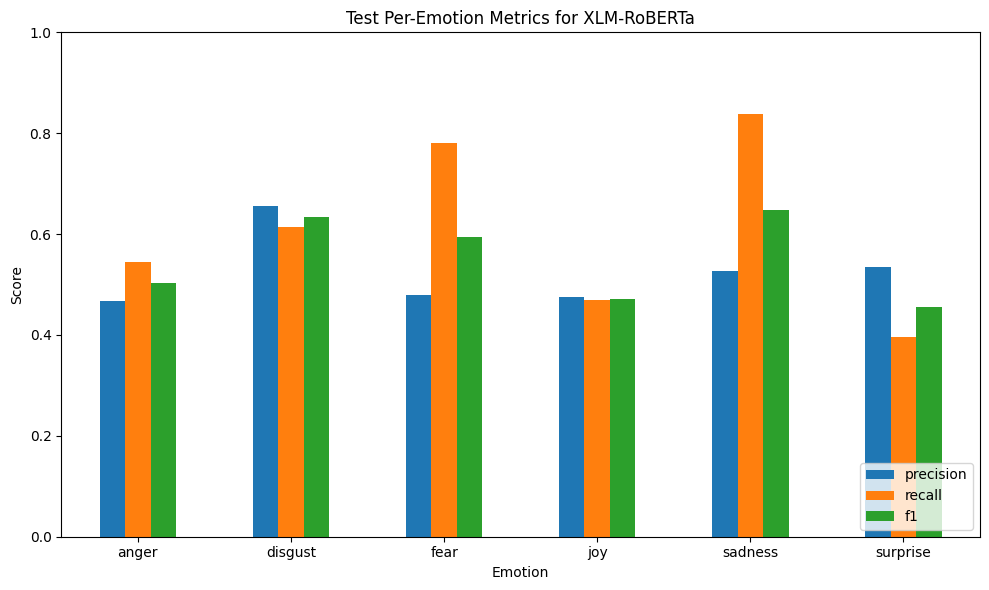

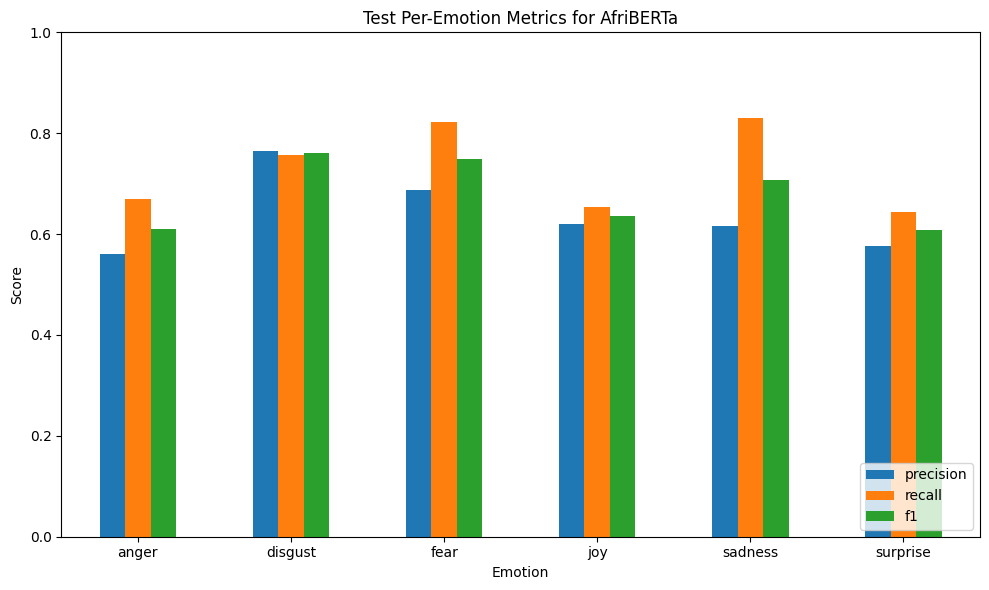

In [ ]:
# ---------------------
# Main Script: Run Experiments & Plot Results
# ---------------------
if __name__ == "__main__":
    train_file = "english_train.parquet"
    test_file = "english_test.parquet"

    results = {}
    model_checkpoints = {
        "XLM-RoBERTa": "xlm-roberta-base",
        "AfriBERTa": "castorini/afriberta_large"
    }

    for model_name, checkpoint in model_checkpoints.items():
        results[model_name] = run_experiment(checkpoint, train_file, test_file)

    overall_dict = {}
    for model, metric_values in results.items():
        overall_dict[model] = metric_values["overall_test"]
        print(f"\nModel: {model}")
        print("Overall Test Metrics:")
        for k, v in metric_values["overall_test"].items():
            print(f"  {k}: {v:.4f}")
        print("Per-Emotion Test Metrics:")
        for emotion, metrics in metric_values["per_emotion_test"].items():
            print(f"  {emotion}: p={metrics['precision']:.4f}, r={metrics['recall']:.4f}, f1={metrics['f1']:.4f}")

    model_names = list(overall_dict.keys())
    plot_overall_metrics(overall_dict, model_names, dataset_type="Test")

    for model in model_names:
        plot_per_emotion_metrics(results[model]["per_emotion_test"], model, dataset_type="Test")


In [ ]:
def predict_emotion(sentence, model, tokenizer, threshold=0.3):
    """
    Predict the emotion(s) present in a given sentence.

    Args:
      sentence (str): Input text.
      model: Your fine-tuned (PEFT) model.
      tokenizer: The corresponding tokenizer.
      threshold (float): Sigmoid threshold for deciding if an emotion is present.

    Returns:
      A tuple containing:
        - A list of predicted emotion labels.
        - The raw probability values for all emotions.
    """
    model.eval()  # Set the model to evaluation mode.
    # Tokenize the sentence; note the same max_length used during training.
    inputs = tokenizer(sentence,
                       return_tensors="pt",
                       truncation=True,
                       padding="max_length",
                       max_length=MAX_LEN)

    # Move inputs to the same device your model is on.
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        output = model(**inputs)

    # Get logits and apply sigmoid to produce probabilities.
    logits = output.logits
    probs = torch.sigmoid(logits).cpu().numpy()[0]
    # Apply threshold to decide which emotions are predicted
    preds = (probs > threshold).astype("int32")
    predicted_labels = [emotion_labels[i] for i, value in enumerate(preds) if value == 1]

    return predicted_labels, probs

# Example usage:
sentence = "Ina matukar farin ciki da farin ciki game da sabon kasada na!"
predicted_emotions, probability_values = predict_emotion(sentence, peft_model, tokenizer)

print("Input Sentence:", sentence)
print("Predicted Emotions:", predicted_emotions)
print("Probability Values:", probability_values)

NameError: name 'peft_model' is not defined